# Faza 2: Iskanje asociacijskih pravil in izbira značilk

**Zastavljen cilj**: V tej fazi smo poiskali medsebojne odvisnosti med različnimi kategoričnimi in diskretiziranimi numeričnimi značilkami, zlasti takšnimi, ki pogosto vodijo v neplačilo (status 1). Hkrati smo zmanjšali število spremenljivk (izbira značilk), da bi izboljšali in pohitrili učenje kompleksnih modelov v naslednjih fazah.

Dokument je napisan v formatu končnega poročila. Naloge programiranja (implementacijo) smo prepustili ekipi.

## 1. Uvoz knjižnic in priprava predprocesiranih podatkov

Naložili smo procesirano in očiščeno bazo iz prejšnje faze (`train_processed.csv` in `test_processed.csv`). Poleg standardnih knjižnic (`pandas`, `matplotlib`) smo za iskanje pravil uporabili knjižnico `mlxtend`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mlxtend.frequent_patterns import apriori, association_rules

# TODO (ekipa): Naložite `../data/train_processed.csv` v obliko `train_df` in `../data/test_processed.csv` v `test_df`.
# TODO (ekipa): Preverite osnovne dimenzije (npr. .shape, .head()).

train_df = pd.read_csv("../data/train_processed.csv")
test_df = pd.read_csv("../data/test_processed.csv")


## 2. Diskretizacija (Binning) za algoritem Apriori

Ker algoritmi za iskanje asociacijskih pravil delujejo le na diskretnih postavkah (ang. *itemsets*), smo morali ključne zvezne spremenljivke najprej preoblikovati v kategorije oz. intervale.

Zvezne atribute, kot so višina posojila, obrestna mera in razmerje DTI, smo razdelili v tri razrede (*Low*, *Medium*, *High*).

In [2]:
# TODO (ekipa): Ustvarite nov DataFrame `apriori_df` kot kopijo train množice za namen iskanja pravil.
# TODO (ekipa): Z uporabo `pd.qcut` diskretizirajte spremenljivko `loan_amnt` v tri intervale z oznakami (npr. 'Low', 'Med', 'High').
# TODO (ekipa): Enako diskretizacijo napravite za `annual_inc`, `int_rate` in `dti`.

apriori_df = train_df.copy()

apriori_df['loan_amnt_bin'] = pd.qcut(
    apriori_df['loan_amnt'],
    q=3,
    labels=['Low', 'Med', 'High']
)
apriori_df['annual_inc_bin'] = pd.qcut(
    apriori_df['annual_inc'],
    q=3,
    labels=['Low', 'Med', 'High']
)
apriori_df['int_rate_bin'] = pd.qcut(
    apriori_df['int_rate'],
    q=3,
    labels=['Low', 'Med', 'High']
)
apriori_df['dti_bin'] = pd.qcut(
    apriori_df['dti'],
    q=3,
    labels=['Low', 'Med', 'High']
)

In [3]:
print(apriori_df[['loan_amnt_bin', 'annual_inc_bin', 'int_rate_bin', 'dti_bin']].head())

  loan_amnt_bin annual_inc_bin int_rate_bin dti_bin
0          High           High         High     Med
1          High           High          Low     Low
2           Med            Low          Low    High
3          High           High         High     Low
4           Low           High          Low     Low


## 3. Generiranje pogostih postavk in asociacijskih pravil

Podatke smo ponovno preoblikovali s pomočjo binarnega kodiranja (*One-Hot Encoding*), kjer je vsak stolpec predstavljal pravilnost neke postavke (True/False). Z uporabo algoritma **Apriori** smo poiskali nabor pogostih postavk (*Frequent Itemsets*).

Iz izluščenih postavk smo ustvarili pravila in analizirali njihovo zaupanje (*confidence*) ter dvig (*lift*).

In [4]:
# TODO (ekipa): Vse diskretizirane in kategorične spremenljivke iz `apriori_df` pretvorite v boolean matriko z uporabo `pd.get_dummies(..., dtype=bool)`.
# TODO (ekipa): Zaženite `apriori(bool_df, min_support=0.05, use_colnames=True)`.
# TODO (ekipa): Zaženite `association_rules()` nad pogostimi postavkami (izberite metriko 'lift').
# TODO (ekipa): Izpišite prvih 10 pridobljenih pravil, razvrščenih padajoče po izbrani metriki.

kategorije_obj = apriori_df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
kategorije_bin = ['loan_amnt_bin', 'annual_inc_bin', 'int_rate_bin', 'dti_bin']
kategorije_vse = list(set(kategorije_obj + kategorije_bin))

razpolozljive = [col for col in kategorije_vse if col in apriori_df.columns]

bool_df = pd.get_dummies(apriori_df[razpolozljive], dtype=bool)
bool_df = bool_df.astype(bool)

frequent_itemsets = apriori(bool_df, min_support=0.05, use_colnames=True)
print(f"Število najdenih pogostih naborov: {len(frequent_itemsets)}")

rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)
print(f"Število generiranih pravil: {len(rules)}")


stolpci_status = [col for col in bool_df.columns if 'loan_status_label' in col]
print("\nStolpci za status posojila po One‑Hot kodiranju:")
print(stolpci_status)

if 'loan_status_label_1' in stolpci_status:
    ime_neplacilo = 'loan_status_label_1'
elif 'loan_status_label_Neplačano' in stolpci_status:
    ime_neplacilo = 'loan_status_label_Neplačano'
else:
    ime_neplacilo = [c for c in stolpci_status if 'Plačano' not in c][0]

print(f"\nIščemo pravila s konsekvensom: '{ime_neplacilo}'")


pravila_neplacilo = rules[rules['consequents'].apply(lambda x: ime_neplacilo in x)]

if not pravila_neplacilo.empty:
    top_neplacilo = pravila_neplacilo.sort_values('lift', ascending=False).head(10).copy()
    
    # Funkcija za lepši zapis množic
    def format_itemset(itemset):
        return ', '.join(sorted(itemset))
    
    top_neplacilo['antecedents'] = top_neplacilo['antecedents'].apply(format_itemset)
    top_neplacilo['consequents'] = top_neplacilo['consequents'].apply(format_itemset)
    
    pd.set_option('display.max_colwidth', 60)
    pd.set_option('display.precision', 4)
    
    print("\nTop 10 asociacijskih pravil, ki vodijo v NE PLAČILO:")
    display(top_neplacilo[['antecedents', 'consequents', 'support', 'confidence', 'lift']]
            .style.format({'support': '{:.4f}', 'confidence': '{:.2%}', 'lift': '{:.2f}'})
            .background_gradient(subset=['lift'], cmap='Reds')
            .set_caption("Pravila za neplačilo (status 1)"))
else:
    print("\n Ni pravil z neplačilom. Poskusite znižati 'min_support' na 0.02 ali 0.01.")

# (Neobvezno) Izpišemo tudi vsa najmočnejša pravila ne glede na status
print("\n" + "="*70)
print("Vsa najmočnejša pravila (brez filtriranja):")
top_all = rules.sort_values('lift', ascending=False).head(10).copy()
top_all['antecedents'] = top_all['antecedents'].apply(format_itemset)
top_all['consequents'] = top_all['consequents'].apply(format_itemset)
display(top_all[['antecedents', 'consequents', 'support', 'confidence', 'lift']]
        .style.format({'support': '{:.4f}', 'confidence': '{:.2%}', 'lift': '{:.2f}'})
        .background_gradient(subset=['lift'], cmap='Blues')
        .set_caption("Top 10 vseh pravil po liftu"))

Število najdenih pogostih naborov: 674
Število generiranih pravil: 2848

Stolpci za status posojila po One‑Hot kodiranju:
['loan_status_label_Neplačano', 'loan_status_label_Plačano']

Iščemo pravila s konsekvensom: 'loan_status_label_Neplačano'

Top 10 asociacijskih pravil, ki vodijo v NE PLAČILO:


,antecedents,consequents,support,confidence,lift
1142,"home_ownership_RENT, int_rate_bin_High",loan_status_label_Neplačano,0.0500,35.91%,1.80
518,"int_rate_bin_High, purpose_debt_consolidation",loan_status_label_Neplačano,0.0691,33.72%,1.69
521,int_rate_bin_High,"loan_status_label_Neplačano, purpose_debt_consolidation",0.0691,21.17%,1.69
1146,int_rate_bin_High,"home_ownership_RENT, loan_status_label_Neplačano",0.0500,15.33%,1.66
127,int_rate_bin_High,loan_status_label_Neplačano,0.1044,32.01%,1.60
564,"dti_bin_High, purpose_debt_consolidation",loan_status_label_Neplačano,0.0554,26.65%,1.34
567,dti_bin_High,"loan_status_label_Neplačano, purpose_debt_consolidation",0.0554,16.64%,1.33
137,dti_bin_High,loan_status_label_Neplačano,0.0838,25.15%,1.26
412,"home_ownership_RENT, purpose_debt_consolidation",loan_status_label_Neplačano,0.0576,24.38%,1.22
572,loan_amnt_bin_High,"loan_status_label_Neplačano, purpose_debt_consolidation",0.0503,15.20%,1.21



Vsa najmočnejša pravila (brez filtriranja):


,antecedents,consequents,support,confidence,lift
2147,"annual_inc_bin_High, verification_status_Verified","home_ownership_MORTGAGE, loan_amnt_bin_High",0.0511,47.81%,2.40
2150,"home_ownership_MORTGAGE, loan_amnt_bin_High","annual_inc_bin_High, verification_status_Verified",0.0511,25.65%,2.40
2144,"annual_inc_bin_High, home_ownership_MORTGAGE, verification_status_Verified",loan_amnt_bin_High,0.0511,74.30%,2.24
2153,loan_amnt_bin_High,"annual_inc_bin_High, home_ownership_MORTGAGE, verification_status_Verified",0.0511,15.44%,2.24
2713,"annual_inc_bin_High, loan_status_label_Plačano","int_rate_bin_Low, loan_amnt_bin_High",0.0617,22.79%,2.23
2716,"int_rate_bin_Low, loan_amnt_bin_High","annual_inc_bin_High, loan_status_label_Plačano",0.0617,60.50%,2.23
2756,annual_inc_bin_High,"dti_bin_Low, loan_amnt_bin_High, loan_status_label_Plačano",0.0594,18.12%,2.20
2749,"dti_bin_Low, loan_amnt_bin_High, loan_status_label_Plačano",annual_inc_bin_High,0.0594,72.10%,2.20
2161,"annual_inc_bin_High, verification_status_Verified","loan_amnt_bin_High, loan_status_label_Plačano",0.0599,55.99%,2.18
2162,"loan_amnt_bin_High, loan_status_label_Plačano","annual_inc_bin_High, verification_status_Verified",0.0599,23.34%,2.18


### 3.1 Pravila, ki nakazujejo na neplačilo (Default)

Najbolj so nas zanimala tista pravila, katerih posledica je nakazovala na izpad plačila kredita (`loan_status_1`).
Ustrezno smo filtrirali izpisana pravila, da smo lahko opazili kritične povezave med določenimi specifikami strank in neplačilom.

In [5]:
# TODO (ekipa): Iz dataframe-a asociacijskih pravil izluščite samo takšna, kjer stolpec `consequents` vsebuje indikator neplačila (npr. `loan_status_1`).
# TODO (ekipa): Filtrirana pravila razvrstite po `confidence` in izpišite prvih 10.
# TODO (ekipa): V ločeni Markdown celici ali pa s komentarjem na kratko opišite svoje ugotovitve (Kateri profili najpogosteje "default-ajo"?).

ime_neplacilo = 'loan_status_label_Neplačano'   

default_rules = rules[rules['consequents'].apply(lambda x: ime_neplacilo in x)]

top_default_confidence = default_rules.sort_values('confidence', ascending=False).head(10).copy()

def format_itemset(itemset):
    return ', '.join(sorted(itemset))

top_default_confidence['antecedents'] = top_default_confidence['antecedents'].apply(format_itemset)
top_default_confidence['consequents'] = top_default_confidence['consequents'].apply(format_itemset)

from IPython.display import display
display(top_default_confidence[['antecedents', 'consequents', 'support', 'confidence', 'lift']]
        .style.format({'support': '{:.4f}', 'confidence': '{:.2%}', 'lift': '{:.2f}'})
        .background_gradient(subset=['lift'], cmap='Reds')
        .set_caption("Top 10 pravil za neplačilo – razvrščeno po zaupanju"))


,antecedents,consequents,support,confidence,lift
1142,"home_ownership_RENT, int_rate_bin_High",loan_status_label_Neplačano,0.0500,35.91%,1.80
518,"int_rate_bin_High, purpose_debt_consolidation",loan_status_label_Neplačano,0.0691,33.72%,1.69
127,int_rate_bin_High,loan_status_label_Neplačano,0.1044,32.01%,1.60
564,"dti_bin_High, purpose_debt_consolidation",loan_status_label_Neplačano,0.0554,26.65%,1.34
137,dti_bin_High,loan_status_label_Neplačano,0.0838,25.15%,1.26
412,"home_ownership_RENT, purpose_debt_consolidation",loan_status_label_Neplačano,0.0576,24.38%,1.22
570,"loan_amnt_bin_High, purpose_debt_consolidation",loan_status_label_Neplačano,0.0503,24.14%,1.21
49,verification_status_Verified,loan_status_label_Neplačano,0.0736,23.89%,1.20
92,home_ownership_RENT,loan_status_label_Neplačano,0.0924,23.18%,1.16
364,"purpose_debt_consolidation, verification_status_Source Verified",loan_status_label_Neplačano,0.0526,23.00%,1.15


Najpogosteje ne plačajo komitenti z visoko obrestno mero, najemniki ter tisti, ki posojilo najemajo za konsolidacijo dolgov

## 4. Izbira najvplivnejših značilk (Feature Selection)

Zaradi preprečevanja prevelikega prilagajanja (*overfitting*) in odvečnega šuma smo izvedli zmanjšanje obsega dimenzij. Uporabili smo model Naključnega gozda (*Random Forest Classifier*) in na osnovi rezultatov obdržali samo najpomembnejše dejavnike (*Feature Importances*).

To operacijo smo izvedli izključno na učnem naboru podatkov po predprocesiranju (`train_processed`).

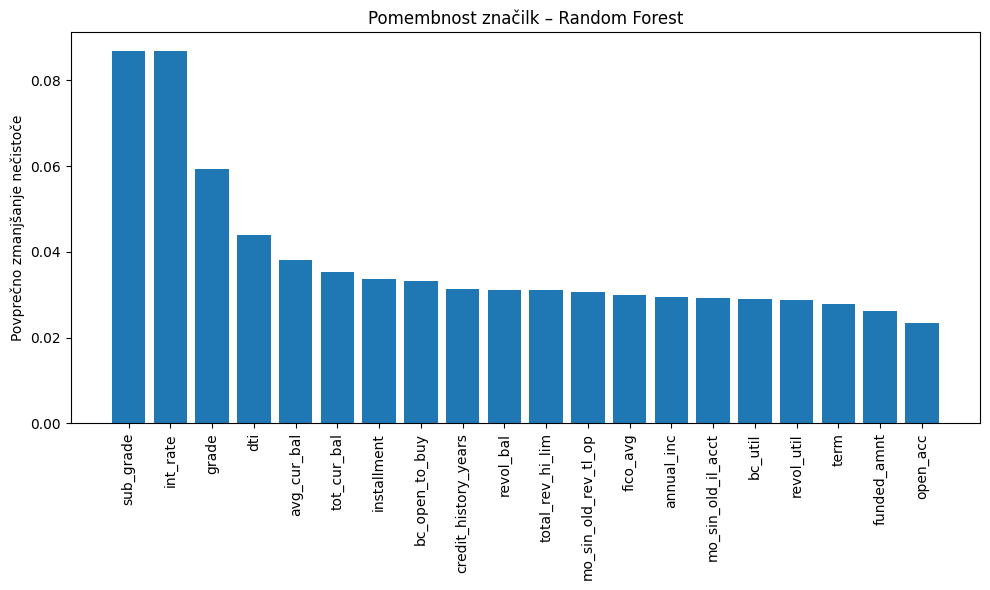

Vse značilke razvrščene po pomembnosti:


,feature,importance
6,sub_grade,0.0869
3,int_rate,0.0868
5,grade,0.0594
9,dti,0.0440
20,avg_cur_bal,0.0380
17,tot_cur_bal,0.0353
4,installment,0.0336
21,bc_open_to_buy,0.0332
36,credit_history_years,0.0313
14,revol_bal,0.0312



Prvih 33 značilk pojasni 95 % skupne pomembnosti.

Izbrane značilke (prvih 15):
['sub_grade', 'int_rate', 'grade', 'dti', 'avg_cur_bal', 'tot_cur_bal', 'installment', 'bc_open_to_buy', 'credit_history_years', 'revol_bal', 'total_rev_hi_lim', 'mo_sin_old_rev_tl_op', 'fico_avg', 'annual_inc', 'mo_sin_old_il_acct']


In [6]:
from sklearn.ensemble import RandomForestClassifier

# TODO (ekipa): Definirajte in prilegajte (`.fit`) model `RandomForestClassifier` na strukturi `train_df`. Pri tem besedilna polja odstranite od učenja.
# TODO (ekipa): Pridobite padajoče vrednosti značilk `.feature_importances_` in jih vizualizirajte na vrstičnem grafikonu (bar plot).
# TODO (ekipa): Naredite odločitev in obdržite prvih N najpomembnejših spremenljivk.

target_col = 'loan_status_label'

text_cols_to_drop = ['emp_title', 'desc']
leakage_cols = ['loan_status']          

all_drop = text_cols_to_drop + leakage_cols + [target_col]
cols_to_drop = [col for col in all_drop if col in train_df.columns]

X = train_df.drop(columns=cols_to_drop, errors='ignore')
y = train_df[target_col]

# Preverimo, ali so v X še kakšni ne‑številski stolpci 
non_numeric_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
if non_numeric_cols:
    X = pd.get_dummies(X, columns=non_numeric_cols, drop_first=True)

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf.fit(X, y)

importances = rf.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[::-1]  

plt.figure(figsize=(10, 6))
plt.title("Pomembnost značilk – Random Forest")
plt.bar(range(min(20, len(importances))), importances[indices[:20]], align='center')
plt.xticks(range(min(20, len(importances))), feature_names[indices[:20]], rotation=90)
plt.ylabel("Povprečno zmanjšanje nečistoče")
plt.tight_layout()
plt.show()

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)
print("Vse značilke razvrščene po pomembnosti:")
display(importance_df.head(20))

importance_df['cumulative_importance'] = importance_df['importance'].cumsum()
N_95 = (importance_df['cumulative_importance'] < 0.95).sum() + 1
print(f"\nPrvih {N_95} značilk pojasni 95 % skupne pomembnosti.")

N_fixed = 15
selected_features = importance_df.head(N_fixed)['feature'].tolist()

print(f"\nIzbrane značilke (prvih {N_fixed}):")
print(selected_features)


## 5. Shranjevanje optimizirane množice

Ob upoštevanju zgornjih ugotovitev smo izhodno zmanjšano množico atributov na učnem in testnem naboru prepisali. Besedilni stolpci niso bili predmet redukcije, zato smo jih skrbno obdržali. Skrajšano in optimizirano verzijo smo izvozili v nove datoteke.

In [7]:
# TODO (ekipa): Obrežite in obdržite samo izbran nabor stolpcev iz `train_df` in `test_df`. (Ne pozabite ohraniti ciljne spremenljivke in tekstovnih polj!)
# TODO (ekipa): Shranite tako pripravljeni datoteki kot `../data/train_selected.csv` in `../data/test_selected.csv`.


selected_features = ['sub_grade', 'int_rate', 'grade', 'dti', 'avg_cur_bal', 
                     'tot_cur_bal', 'installment', 'bc_open_to_buy', 'credit_history_years', 
                     'revol_bal', 'total_rev_hi_lim', 'mo_sin_old_rev_tl_op', 'fico_avg', 
                     'annual_inc', 'mo_sin_old_il_acct']

target_col = 'loan_status_label'
text_cols = ['emp_title', 'desc']          

id_cols = [col for col in train_df.columns if 'id' in col.lower()]  # prilagodite

cols_to_keep = selected_features + [target_col] + text_cols + id_cols

cols_to_keep = list(dict.fromkeys(cols_to_keep))

train_cols_keep = [col for col in cols_to_keep if col in train_df.columns]
test_cols_keep  = [col for col in cols_to_keep if col in test_df.columns]

train_selected = train_df[train_cols_keep].copy()
test_selected  = test_df[test_cols_keep].copy()

print(f"Dimenzije učne množice po izbiri: {train_selected.shape}")
print(f"Dimenzije testne množice po izbiri: {test_selected.shape}")

# CSV datoteke
train_selected.to_csv("../data/train_selected.csv", index=False)
test_selected.to_csv("../data/test_selected.csv", index=False)


Dimenzije učne množice po izbiri: (16000, 19)
Dimenzije testne množice po izbiri: (4000, 19)
